## imports

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# decompistion
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# dataset manipulation
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# classifcation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score

# regression
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# decision
from sklearn.tree import DecisionTreeClassifier

# ensemble
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier

# google drive
from google.colab import drive

- mount google drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data loading

- load dateset

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/B-CODECRUNCH/spotify.csv")

- print the dataset
    - print(date) -> if your not using jupyter notebooks or google colab

## Exploratory Data Analysis (EDA)

In [ ]:
data # print(date)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


- print dataset columns:

In [ ]:
data.columns # print(data.columns)

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

- print dataset info

In [ ]:
data.info() #print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

- generate scatter plot of tempo against loudness colored by song genre
    - if your not using jupyter notebooks or google colab:
        - make sure to add at the end of your code:
            ```
            plt.show()
            ```

<Axes: xlabel='tempo', ylabel='loudness'>

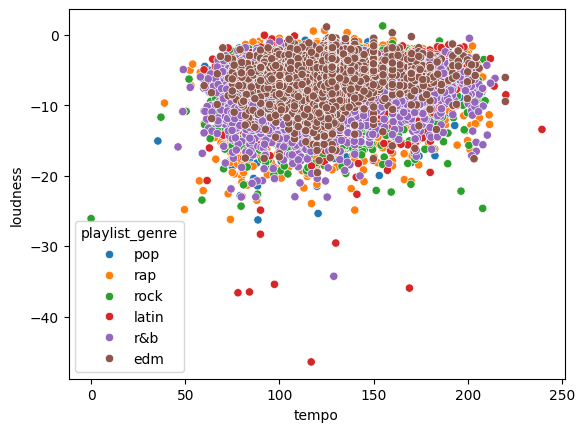

In [ ]:
sns.scatterplot(data,x="tempo",y="loudness",hue="playlist_genre")

- example of getting a subset of a dataset

In [ ]:
data[["playlist_genre","playlist_subgenre"]] #print(data[["playlist_genre","playlist_subgenre"]])

,playlist_genre,playlist_subgenre
0,pop,dance pop
1,pop,dance pop
2,pop,dance pop
3,pop,dance pop
4,pop,dance pop
...,...,...
32828,edm,progressive electro house
32829,edm,progressive electro house
32830,edm,progressive electro house
32831,edm,progressive electro house


- pairplot of various features in the dataset
    - if your not using jupyter notebooks or google colab:
        - make sure to add at the end of your code:
            ```
            plt.show()
            ```

In [ ]:
# sns.pairplot(data[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',"playlist_genre"]],hue="playlist_genre")

- countplot of song genre
    - if your not using jupyter notebooks or google colab:
        - make sure to add at the end of your code:
            ```
            plt.show()
            ```

<Axes: xlabel='playlist_genre', ylabel='count'>

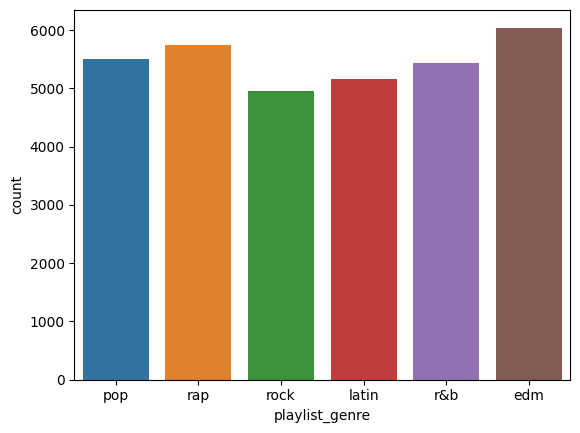

In [ ]:
sns.countplot(data, x="playlist_genre",hue="playlist_genre")

- count plot of subgenres    
    - if your not using jupyter notebooks or google colab:
        - make sure to add at the end of your code:
            ```
            plt.show()
            ```

    - plt.subplots(figsize=(50,5)) creates a plot that has a x axis length of 50 and a y axis length of 5

<Axes: xlabel='playlist_subgenre', ylabel='count'>

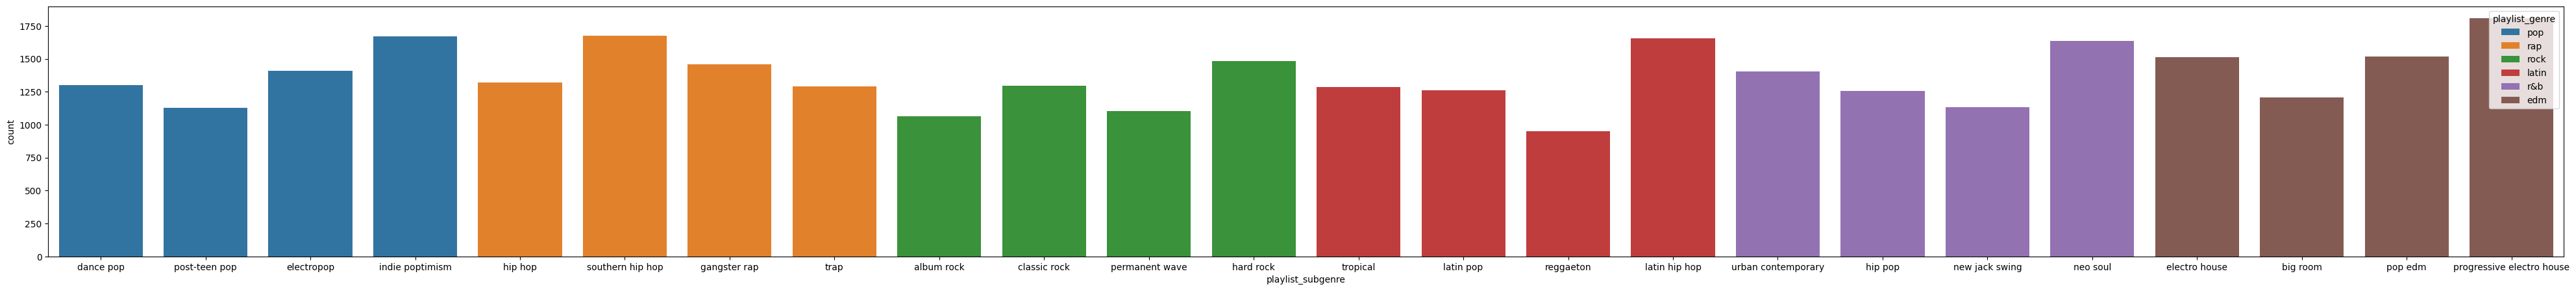

In [ ]:
fig, ax = plt.subplots(figsize=(50, 5))
sns.countplot(data, x="playlist_subgenre",hue="playlist_genre")

## Data Processing

- removing dataset features that were found to be unnecessary for modeling

In [ ]:
d1 = data.drop(["track_name","track_artist","track_album_id","track_album_name","track_album_release_date","playlist_id"],axis=1)

- print new processed dataset

In [ ]:
d1 #print(d1)

,track_id,track_popularity,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,66,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,67,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,70,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,60,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,69,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,42,♥ EDM LOVE 2020,edm,progressive electro house,0.428,0.922,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,20,♥ EDM LOVE 2020,edm,progressive electro house,0.522,0.786,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,14,♥ EDM LOVE 2020,edm,progressive electro house,0.529,0.821,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,15,♥ EDM LOVE 2020,edm,progressive electro house,0.626,0.888,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [ ]:
X = d1[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']]
y = d1[["playlist_genre"]]

In [ ]:
y['playlist_genre'].unique()

array(['pop', 'rap', 'rock', 'latin', 'r&b', 'edm'], dtype=object)

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_encoded

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 2, 2, ..., 0, 0, 0])

- split new dataset to 3% of its original size

# Decompostion/Dimenisionality reduction

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
x_lda = lda.fit_transform(X,y_encoded)

In [ ]:
X = pd.DataFrame(data=x_lda,columns=["f1","f2"])
y = pd.DataFrame(y_encoded,columns=["target"])
data = pd.concat([X,y],axis=1)

Text(0.5, 1.0, 'LDA')

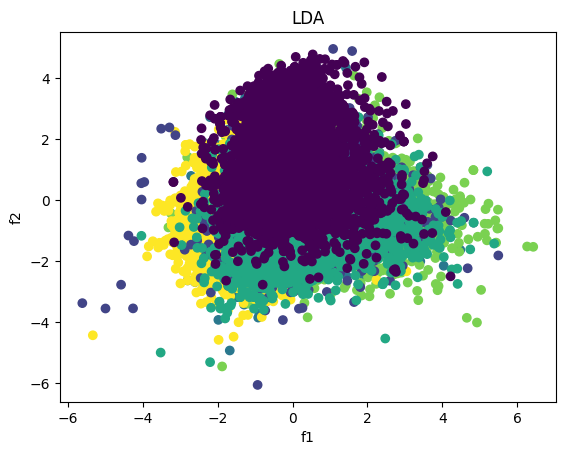

In [ ]:
plt.scatter(data["f1"],data["f2"],c=data["target"],)
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("LDA")

# Clustering

In [ ]:
KM = KMeans(n_clusters=6)
KM.fit(X)
labels = KM.labels_
centers = KM.cluster_centers_
centers

In [ ]:
plt.scatter(X["valence"],X["energy"],c=labels)
plt.scatter(centers[:,0],centers[:,1],marker="x",c="red", s=200)
plt.title("K-Means Clustering")
plt.xlabel("valence")
plt.ylabel("energy")

In [ ]:
silhouette_score(X,labels)

In [ ]:
davies_bouldin_score(X,labels)

In [ ]:
calinski_harabasz_score(X,labels)

In [ ]:
DB = DBSCAN()
DB.fit(X)
labels = DB.labels_

In [ ]:
plt.scatter(X["valence"],X["energy"],c=labels)
plt.title("DBSCAN Clustering")
plt.xlabel("valence")
plt.ylabel("energy")

In [ ]:
# test size = 5%
# temp size = 95%
# valid size = 5%

In [ ]:
 Xtemp, Xtest, ytemp, ytest = train_test_split(X,y,train_size=0.95)
 Xtrain, Xvalid, ytrain, yvalid = train_test_split(Xtemp,ytemp,test_size=(0.05/0.95))

## Exploratory Data Analysis

- print reduced dataset

In [ ]:
(len(yvalid)/len(data))*100

5.001066000670058

In [ ]:
(len(ytest)/len(data))*100

5.001066000670058

In [ ]:
(len(ytrain)/len(data))*100

89.99786799865988

# Ensemble

## Classification

### Stacking

In [ ]:
KNN = KNeighborsClassifier(n_neighbors=4,weights="distance")
LR = LogisticRegression()
DC = DecisionTreeClassifier(max_depth=5)

In [ ]:
base_estimators = [
    ("KNN",KNN),
    ("LR",LR),
    ("DC",DC)
]

In [ ]:
meta_estimator = SVC()

In [ ]:
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5
)

In [ ]:
stacking_model.fit(Xtrain,ytrain)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


StackingClassifier(cv=5,
                   estimators=[('KNN',
                                KNeighborsClassifier(n_neighbors=4,
                                                     weights='distance')),
                               ('LR', LogisticRegression()),
                               ('DC', DecisionTreeClassifier(max_depth=5))],
                   final_estimator=SVC())

In [ ]:
ypred = stacking_model.predict(Xtest)

In [ ]:
accuracy_score(ytest,ypred)

0.4476248477466504